# Deliverable 3
By:


## Import Libraries

In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split 
from sklearn.utils import resample
from sklearn.metrics import confusion_matrix, classification_report, f1_score, ConfusionMatrixDisplay, recall_score, precision_score, roc_auc_score
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import matplotlib.pyplot as plt

## Loading the Dataset, Balancing & Feature Selection

In [2]:
# Load the data from processed_X.csv and processed_y.csv
X = pd.read_csv('..\\datasets\\processed_X.csv')
y = pd.read_csv('..\\datasets\\processed_y.csv')

# Concatenate X and y for easier manipulation
df = pd.concat([X, y], axis=1)

# Balance the dataset using undersampling
class_0 = df[df['Diabetes_binary'] == 0]
class_1 = df[df['Diabetes_binary'] == 1]

class_0_under = class_0.sample(len(class_1), random_state=42)
df_balanced = pd.concat([class_0_under, class_1])
df = df_balanced

print(df.groupby(['Diabetes_binary']).size())

# Select top 10 features based on correlation with the target variable done in the previous notebook
top_features = ["GenHlth", "HighBP", "BMI", "DiffWalk", "HighChol", "Age", "HeartDiseaseorAttack", "PhysHlth", "Income", "Education"]

X = df[top_features]
y = df['Diabetes_binary']

Diabetes_binary
0    35181
1    35181
dtype: int64


In [18]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 70362 entries, 33111 to 236150
Data columns (total 22 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   HighBP                70362 non-null  int64  
 1   HighChol              70362 non-null  int64  
 2   CholCheck             70362 non-null  int64  
 3   BMI                   70362 non-null  float64
 4   Smoker                70362 non-null  int64  
 5   Stroke                70362 non-null  int64  
 6   HeartDiseaseorAttack  70362 non-null  int64  
 7   PhysActivity          70362 non-null  int64  
 8   Fruits                70362 non-null  int64  
 9   Veggies               70362 non-null  int64  
 10  HvyAlcoholConsump     70362 non-null  int64  
 11  AnyHealthcare         70362 non-null  int64  
 12  NoDocbcCost           70362 non-null  int64  
 13  GenHlth               70362 non-null  float64
 14  MentHlth              70362 non-null  float64
 15  PhysHlth           

## Train Test Split, Datasets & DataLoaders

In [3]:
# split the data into training and testing sets
X_temp, X_val, y_temp, y_val = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
X_train, X_test, y_train, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp)

## Shared Pytorh Utilities

In [4]:
class PatientDataset(Dataset):
    def __init__(self, X, y):
        self.num_data = torch.tensor(X.values, dtype=torch.float32)
        self.y = torch.tensor(y.values, dtype=torch.long)

    def __len__(self):
        return len(self.y)

    def __getitem__(self, idx):
        return self.num_data[idx], self.y[idx]

In [5]:
train_ds = PatientDataset(X_train, pd.Series(y_train))
val_ds = PatientDataset(X_val, pd.Series(y_val))
test_ds = PatientDataset(X_test, pd.Series(y_test))

train_loader = DataLoader(train_ds, batch_size=32, shuffle=True)
val_loader = DataLoader(val_ds, batch_size=32)
test_loader = DataLoader(test_ds, batch_size=32)

In [7]:
loss_fn = nn.BCELoss()

In [8]:
device = torch.accelerator.current_accelerator().type if torch.accelerator.is_available() else "cpu"
print(f"Using {device} device")

Using cpu device


In [ ]:
def train(dataloader, model, loss_fn, optimizer):
    size = len(dataloader.dataset)
    model.train()
    epoch_loss = 0
    for batch, (X, y) in enumerate(dataloader):
        X, y = X.to(device), y.to(device)
        y = y.float() 
        y = y.unsqueeze(1) 

        # Compute prediction error
        pred = model(X)
        loss = loss_fn(pred, y)
        epoch_loss += loss.item()

        # Backpropagation
        loss.backward()
        optimizer.step()
        optimizer.zero_grad()

        if batch % 100 == 0:
            loss, current = loss.item(), (batch + 1) * len(X)
            print(f"loss: {loss:>7f}  [{current:>5d}/{size:>5d}]")
    
    epoch_loss /= len(dataloader)
    return epoch_loss

In [21]:
def test(dataloader, model, loss_fn):
    size = len(dataloader.dataset)
    num_batches = len(dataloader)
    model.eval()
    test_loss, correct = 0, 0
    with torch.no_grad():
        for X, y in dataloader:
            X, y = X.to(device), y.to(device)
            y = y.float() 
            y = y.unsqueeze(1) 
            pred = model(X)
            test_loss += loss_fn(pred, y).item()
            correct += ((pred > 0.5) == y).type(torch.float).sum().item()
    test_loss /= num_batches
    correct /= size
    print(f"Test Error: \n Accuracy: {(100*correct):>0.1f}%, Avg loss: {test_loss:>8f} \n")
    return test_loss, correct

In [11]:
epochs = 50

## Simple MLP

### Build the Model

In [12]:
# Define model
class Simple(nn.Module):
    def __init__(self, input_size=10):
        super().__init__()
        self.flatten = nn.Flatten()
        self.layers_stack = nn.Sequential(
            nn.Linear(input_size, 8),
            nn.ReLU(),
            nn.Linear(8, 4),
            nn.ReLU(),
            nn.Linear(4, 1),
            nn.Sigmoid()
        )

    def forward(self, x):
        x = self.flatten(x)
        logits = self.layers_stack(x)
        return logits

simple_model = Simple().to(device)
print(simple_model)

Simple(
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (layers_stack): Sequential(
    (0): Linear(in_features=10, out_features=8, bias=True)
    (1): ReLU()
    (2): Linear(in_features=8, out_features=4, bias=True)
    (3): ReLU()
    (4): Linear(in_features=4, out_features=1, bias=True)
    (5): Sigmoid()
  )
)


In [13]:
optimizer = torch.optim.SGD(simple_model.parameters(), lr=1e-3)

### Model Training

In [26]:
loss_history = []
test_loss_history = []
test_accuracy_history = []

for t in range(epochs):
    print(f"Epoch {t+1}\n-------------------------------")
    epoch_loss = train(train_loader, simple_model, loss_fn, optimizer)
    loss_history.append(epoch_loss)
    test_loss, test_accuracy = test(test_loader, simple_model, loss_fn)
    test_loss_history.append(test_loss)
    test_accuracy_history.append(test_accuracy)


Epoch 1
-------------------------------
loss: 0.570394  [   32/28144]
loss: 0.609980  [  352/28144]
loss: 0.441972  [  672/28144]
loss: 0.513697  [  992/28144]
loss: 0.544494  [ 1312/28144]
loss: 0.563286  [ 1632/28144]
loss: 0.519354  [ 1952/28144]
loss: 0.465547  [ 2272/28144]
loss: 0.441420  [ 2592/28144]
loss: 0.573146  [ 2912/28144]
loss: 0.627641  [ 3232/28144]
loss: 0.545493  [ 3552/28144]
loss: 0.578018  [ 3872/28144]
loss: 0.507477  [ 4192/28144]
loss: 0.438239  [ 4512/28144]
loss: 0.414833  [ 4832/28144]
loss: 0.534712  [ 5152/28144]
loss: 0.585642  [ 5472/28144]
loss: 0.511222  [ 5792/28144]
loss: 0.521292  [ 6112/28144]
loss: 0.572242  [ 6432/28144]
loss: 0.457754  [ 6752/28144]
loss: 0.507609  [ 7072/28144]
loss: 0.457631  [ 7392/28144]
loss: 0.413709  [ 7712/28144]
loss: 0.413487  [ 8032/28144]
loss: 0.676042  [ 8352/28144]
loss: 0.572549  [ 8672/28144]
loss: 0.446708  [ 8992/28144]
loss: 0.617322  [ 9312/28144]
loss: 0.571049  [ 9632/28144]
loss: 0.730472  [ 9952/28144]


### Model Evaluation

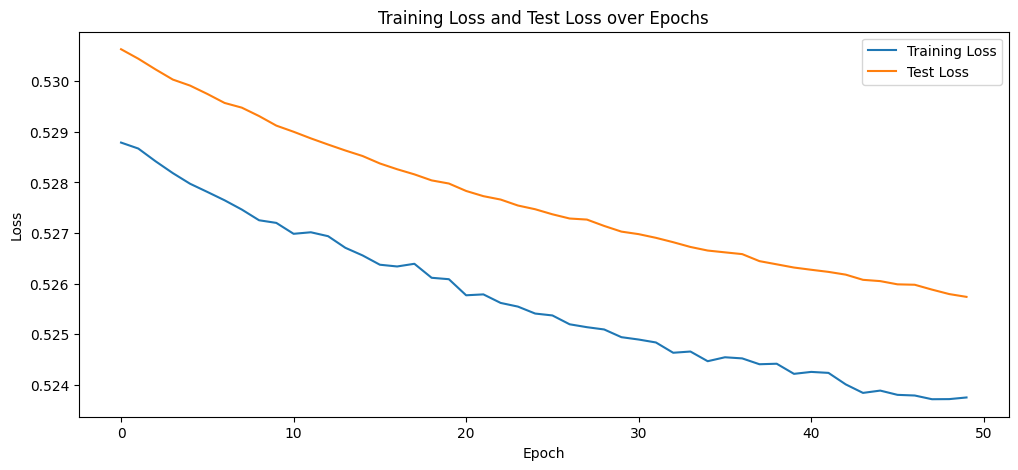

In [ ]:
# Plotting the training loss and test loss history on the same graph
plt.figure(figsize=(12, 5))
plt.plot(loss_history, label='Training Loss')
plt.plot(test_loss_history, label='Test Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training Loss and Test Loss over Epochs')
plt.legend()
plt.show()


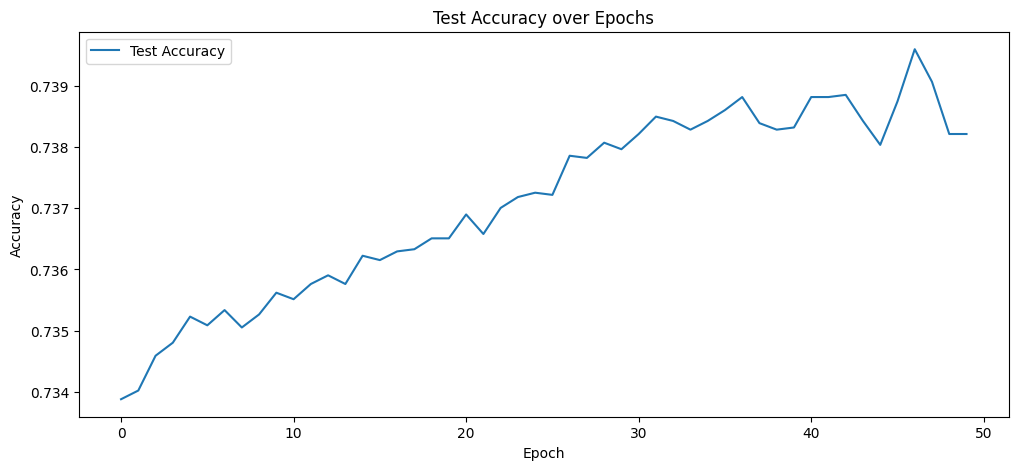

In [28]:
# plotting the test accuracy history
plt.figure(figsize=(12, 5))
plt.plot(test_accuracy_history, label='Test Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Test Accuracy over Epochs')
plt.legend()
plt.show()


In [31]:
# Classification report and confusion matrix
simple_model.eval()
y_true = []
y_pred = []
y_pred_prob = []
with torch.no_grad():
    for X, y in test_loader:
        X, y = X.to(device), y.to(device)
        y = y.float() 
        y = y.unsqueeze(1) 
        pred = simple_model(X)
        y_true.extend(y.cpu().numpy())
        y_pred_prob.extend(pred.cpu().numpy())
        y_pred.extend((pred > 0.5).cpu().numpy())       
y_true = np.array(y_true)
y_pred = np.array(y_pred)
print(classification_report(y_true, y_pred))


              precision    recall  f1-score   support

         0.0       0.77      0.68      0.72     14072
         1.0       0.71      0.80      0.75     14073

    accuracy                           0.74     28145
   macro avg       0.74      0.74      0.74     28145
weighted avg       0.74      0.74      0.74     28145



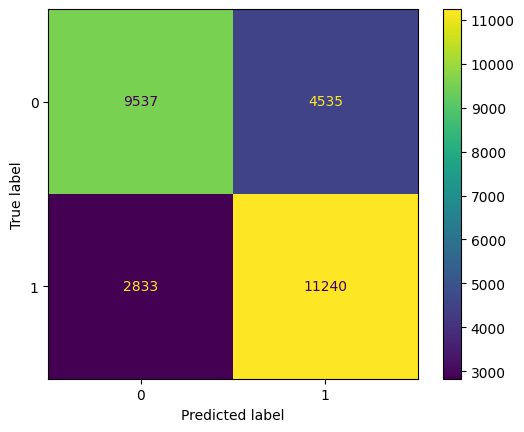

In [30]:
cm = confusion_matrix(y_true, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
plt.show()

### Threshold Analysis

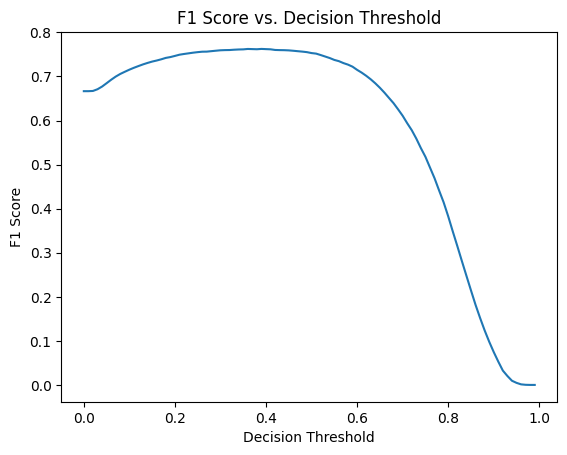

In [32]:
# Generation of the F1 curve based on the decision threshold
thresholds = np.arange(0.0, 1.0, 0.01)
f1_scores = [f1_score(y_test, (y_pred_prob > t).astype(int)) for t in thresholds]

plt.plot(thresholds, f1_scores)
plt.xlabel("Decision Threshold")
plt.ylabel("F1 Score")
plt.title("F1 Score vs. Decision Threshold")
plt.show()

In [33]:
max_f1_index = np.argmax(f1_scores)
optimal_threshold = thresholds[max_f1_index]
print(f"Optimal Threshold: {optimal_threshold:.2f} with F1 Score: {f1_scores[max_f1_index]:.4f}")

Optimal Threshold: 0.39 with F1 Score: 0.7626


In [35]:
# Classification report and confusion matrix
simple_model.eval()
y_true = []
y_pred = []
y_pred_prob = []
with torch.no_grad():
    for X, y in test_loader:
        X, y = X.to(device), y.to(device)
        y = y.float() 
        y = y.unsqueeze(1) 
        pred = simple_model(X)
        y_true.extend(y.cpu().numpy())
        y_pred_prob.extend(pred.cpu().numpy())
        y_pred.extend((pred > optimal_threshold).cpu().numpy())       
y_true = np.array(y_true)
y_pred = np.array(y_pred)
print(classification_report(y_true, y_pred))

              precision    recall  f1-score   support

         0.0       0.82      0.58      0.68     14072
         1.0       0.68      0.88      0.76     14073

    accuracy                           0.73     28145
   macro avg       0.75      0.73      0.72     28145
weighted avg       0.75      0.73      0.72     28145



### ExAI with SHAP & LIME

In [ ]:
# Implement ExAI  with Shap to explain the model's predictions for a few test samples


# Select a few test samples
X_test_samples, y_test_samples = next(iter(test_loader))
X_test_samples, y_test_samples = X_test_samples.to(device), y_test_samples.to(device)

# Initialize the SHAP explainer
explainer = shap.DeepExplainer(simple_model, X_test_samples)

# Compute SHAP values
shap_values = explainer.shap_values(X_test_samples)

# Visualize the SHAP values for the first test sample
shap.initjs()
shap.force_plot(explainer.expected_value[0], shap_values[0][0], X_test_samples[0].cpu().numpy())

## Intermediate MLP

## Enriched MLP

## Comparison of Models